<a href="https://colab.research.google.com/github/tleilani/Phys3130_TM/blob/main/Part2_Project_TinaMojirleilani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Photometry and Color-magnitude Diagrams of Hyades Cluster**

##**Research Question**: *How does the photometric analysis of the Hyades open cluster help to identify cluster members and refine the main sequence fit in the color-magnitude diagram?*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.optimize import curve_fit
!pip install cmasher
import cmasher as cmr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 6.1 MB/s eta 0:00:00


##Upload the CSV downloaded from Gaia DR3

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = '/content/drive/My Drive/GaiaHyades.csv'
df = pd.read_csv(file_path)

df.head()

Mounted at /content/drive


,_r,source_id,ra,dec,ra_error,dec_error,pmra,pmdec,pmra_error,pmdec_error,...,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_bp_rp_excess_factor,astrometric_excess_noise,radial_velocity,radial_velocity_error,pseudocolour,astrometric_params_solved,random_index,ruwe
0,0.006835,3313711171744245376,67.440762,16.951334,1.336095,0.806450,NaN,NaN,NaN,NaN,...,5.178068,21.249388,1.728775,3.665277,NaN,NaN,NaN,3,642703287,NaN
1,0.007097,3313710961290452480,67.448915,16.941143,0.089317,0.052901,-0.090540,-0.213157,0.118705,0.083154,...,95.621700,18.057425,1.210491,0.194187,NaN,NaN,NaN,31,119839485,1.082706
2,0.008413,3313711206104799872,67.441068,16.954212,0.076043,0.045386,0.276723,-2.271709,0.104235,0.072234,...,115.454760,17.764585,1.237321,0.151725,NaN,NaN,NaN,31,836785916,1.048566
3,0.008787,3313710965586523264,67.450888,16.940038,0.079958,0.047849,3.117503,-8.191615,0.107188,0.075236,...,79.141810,18.137140,1.264385,0.000000,NaN,NaN,NaN,31,402596091,0.994331
4,0.009572,3313710999944911104,67.454301,16.954547,0.068955,0.041076,1.205918,-6.204727,0.092875,0.064258,...,98.238240,17.485506,1.446316,0.207372,NaN,NaN,1.435586,95,1211836588,1.098607


In [3]:
c=len(df.columns)
r=len(df)
print(f"Number of columns: {c}")
print(f"Number of rows: {r}")

Number of columns: 26
Number of rows: 100000


#**1.   Data Cleaning**

##Drop the NAN values

In [4]:
# list of columns to check for missing values
required_columns = [
    '_r', 'source_id', 'ra', 'dec', 'ra_error', 'dec_error', 'pmra',
    'pmdec', 'pmra_error', 'pmdec_error', 'parallax', 'parallax_error',
    'phot_g_mean_mag', 'phot_g_mean_flux_over_error',
    'phot_rp_mean_flux_over_error', 'phot_rp_mean_mag',
    'phot_bp_mean_flux_over_error', 'phot_bp_mean_mag',
    'phot_bp_rp_excess_factor','astrometric_excess_noise','ruwe']

# drop rows with NaNs in any of the listed columns
df_cleaned = df.dropna(subset=required_columns)

# index reset
df_cleaned.reset_index(drop=True, inplace=True)

# show the remaining rows
print(f"Remaining rows after dropping NaNs: {df_cleaned.shape[0]}")

Remaining rows after dropping NaNs: 83659


##Drop RUWE > 1.4


####Based on this exact quote from the Gaia archive we filter out the bad fit: "The RUWE is expected to be around 1.0 for sources where the single-star model provides a good fit to the astrometric observations. A value significantly greater than 1.0 (say, >1.4) could indicate that the source is non-single or otherwise problematic for the astrometric solution."

In [5]:
# show the data with the bad fit (ruwe >1.4) citation:https://gea.esac.esa.int/archive/documentation/GDR2/Gaia_archive/chap_datamodel/sec_dm_main_tables/ssec_dm_ruwe.html
df_cleaned[df_cleaned['ruwe']>1.4]

,_r,source_id,ra,dec,ra_error,dec_error,pmra,pmdec,pmra_error,pmdec_error,...,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_bp_rp_excess_factor,astrometric_excess_noise,radial_velocity,radial_velocity_error,pseudocolour,astrometric_params_solved,random_index,ruwe
18,0.025026,3313710518909164288,67.443332,16.923222,1.572563,0.916662,5.546497,-3.283183,2.449080,1.579565,...,9.884301,21.084484,1.877806,8.809955,NaN,NaN,0.845522,95,109325502,1.721216
129,0.064681,3313711480982605440,67.380609,16.935742,0.034020,0.019476,3.612133,2.690514,0.047783,0.032218,...,1314.429700,14.417553,1.231926,0.267134,62.315810,3.314486,NaN,31,740115170,2.361625
136,0.067011,3313711480982605568,67.377848,16.937296,0.112909,0.068447,0.227984,-5.840378,0.153225,0.104173,...,183.722850,15.090549,1.264302,1.040649,-10.202939,4.965790,NaN,31,832767815,6.334486
216,0.082620,3313335478069995008,67.531856,16.932612,0.856216,0.538142,-1.115724,2.109810,1.238385,0.867179,...,12.680356,20.891146,1.252193,5.659485,NaN,NaN,1.192073,95,1136831164,1.523940
244,0.086932,3313712374334438528,67.389279,17.015154,0.854562,0.543828,1.120162,-14.031444,1.131489,0.868409,...,9.287266,21.036728,1.671049,6.469525,NaN,NaN,0.877185,95,32828794,2.308342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83499,1.837694,3314076995582689792,65.872597,18.007271,0.020871,0.011475,1.704182,-9.973379,0.030791,0.022165,...,1945.866200,12.463140,1.218090,0.150909,-20.320835,1.106750,NaN,31,1557015458,1.648408
83533,1.838105,3312582999799715584,68.783738,15.631776,0.112635,0.069248,0.454803,-0.081831,0.161824,0.113240,...,97.003340,18.099155,1.365072,0.729000,NaN,NaN,NaN,31,1386935642,1.459339
83569,1.838576,3313517279742441344,69.007118,18.027948,0.044366,0.026341,0.415749,-1.657792,0.060605,0.042706,...,337.074400,16.149590,1.293275,0.293579,NaN,NaN,NaN,31,1245252888,1.522868
83583,1.838768,3312576407025965312,68.702341,15.559212,1.662497,0.953335,2.037946,-6.650412,2.480230,1.837015,...,4.201529,21.220034,2.367204,10.963183,NaN,NaN,1.333918,95,232506558,3.651638


In [6]:
# after filtering out the 'ruwe'>1.4, we call the new data good_fit. it can be seen below that the number of rows dropped significantly
good_fit = df_cleaned[df_cleaned['ruwe']<1.4]
g =len(good_fit)
print(f"Number of rows after filtering out 'ruwe'>1.4: {g}")

Number of rows after filtering out 'ruwe'>1.4: 81335


#**2. Calculate total proper motion**


###Gaia data provides proper motion in RA and DEC. Thus, by using the Pythagorean theorem we can calculate the total proper motion.

In [7]:
# total proper motion (mas/yr)
good_fit['pm_total'] = np.sqrt(good_fit['pmra']**2 + good_fit['pmdec']**2)

print(good_fit[['pmra', 'pmdec', 'pm_total']].head())

       pmra     pmdec  pm_total
0 -0.090540 -0.213157  0.231589
1  0.276723 -2.271709  2.288501
2  3.117503 -8.191615  8.764781
3  1.205918 -6.204727  6.320829
4  0.192536 -1.485357  1.497784


<ipython-input-7-3640fcf7bc77>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_fit['pm_total'] = np.sqrt(good_fit['pmra']**2 + good_fit['pmdec']**2)


In [8]:
# calculate error using error propogation formula
numerator = np.sqrt((good_fit['pmra']**2 * good_fit['pmra_error']**2) +(good_fit['pmdec']**2 * good_fit['pmdec_error']**2))
denominator = good_fit['pm_total']

# avoid dividing by zero
good_fit['pm_total_error'] = numerator / denominator.replace(0, np.nan)

good_fit[['pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'pm_total', 'pm_total_error']].head()

<ipython-input-8-4e11f0a09eba>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_fit['pm_total_error'] = numerator / denominator.replace(0, np.nan)


,pmra,pmra_error,pmdec,pmdec_error,pm_total,pm_total_error
0,-0.090540,0.118705,-0.213157,0.083154,0.231589,0.089507
1,0.276723,0.104235,-2.271709,0.072234,2.288501,0.072803
2,3.117503,0.107188,-8.191615,0.075236,8.764781,0.079987
3,1.205918,0.092875,-6.204727,0.064258,6.320829,0.065519
4,0.192536,0.408293,-1.485357,0.313309,1.497784,0.315111


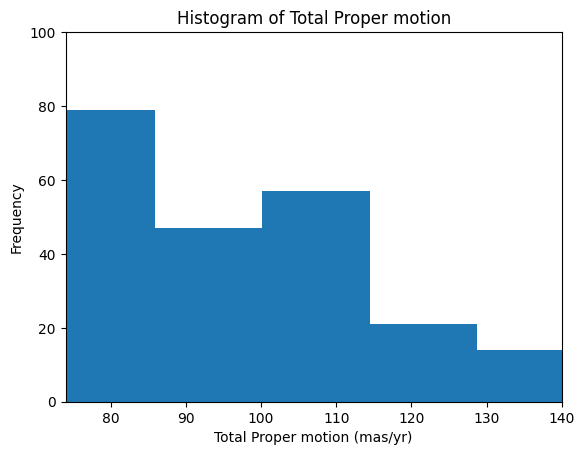

In [9]:
plt.hist(good_fit["pm_total"], bins=30)
plt.xlabel("Total Proper motion (mas/yr)")
plt.ylabel("Frequency")
plt.title("Histogram of Total Proper motion")
plt.xlim(74,140)
plt.ylim(0,100)
plt.show()

#**3. Color-Magnitude Diagram before distinguishing cluster members from background stars**

<ipython-input-10-562a6841c2b5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_fit['bp-rp'] = good_fit['phot_bp_mean_mag'] - good_fit['phot_rp_mean_mag']
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
<ipython-input-10-562a6841c2b5>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_fit['MG'] = good_fit['phot_g_mean_mag'] + 5 * (np.log10(good_fit['parallax'] / 1000) + 1)


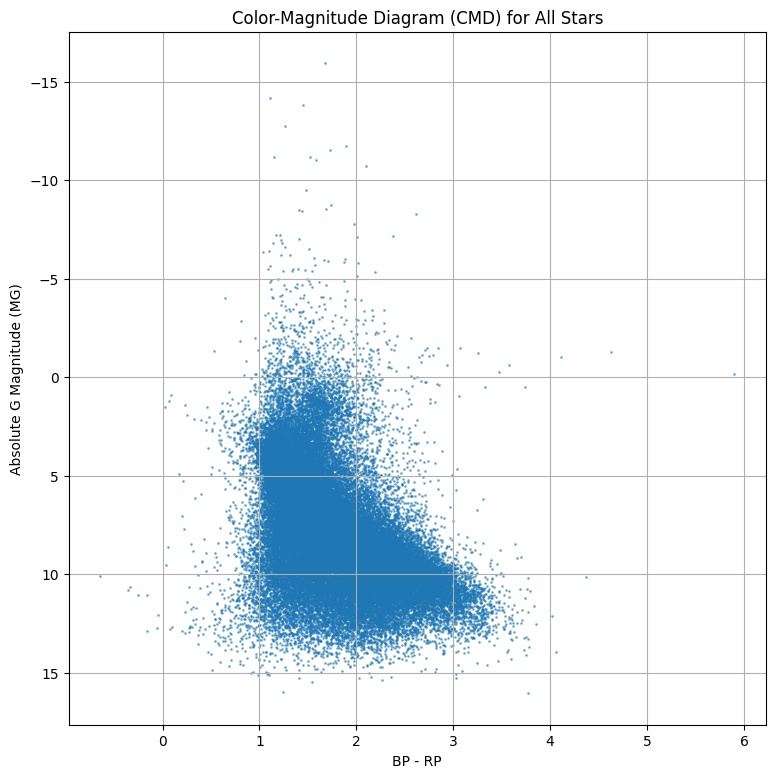

In [10]:
# color (BP - RP)
good_fit['bp-rp'] = good_fit['phot_bp_mean_mag'] - good_fit['phot_rp_mean_mag']

# absolute G magnitude (MG)
good_fit['MG'] = good_fit['phot_g_mean_mag'] + 5 * (np.log10(good_fit['parallax'] / 1000) + 1)

# CMD (BP - RP vs MG) plot
plt.figure(figsize=(9, 9))
plt.scatter(good_fit['bp-rp'], good_fit['MG'], s=1, alpha=0.5)
# invert y axis because we want brighter stars on top. (citation:https://stackoverflow.com/questions/2051744/how-to-invert-the-x-or-y-axis)
plt.gca().invert_yaxis()
plt.xlabel('BP - RP')
plt.ylabel('Absolute G Magnitude (MG)')
plt.title('Color-Magnitude Diagram (CMD) for All Stars')
plt.grid(True)
plt.show()


# **4. Correlation Heatmap**

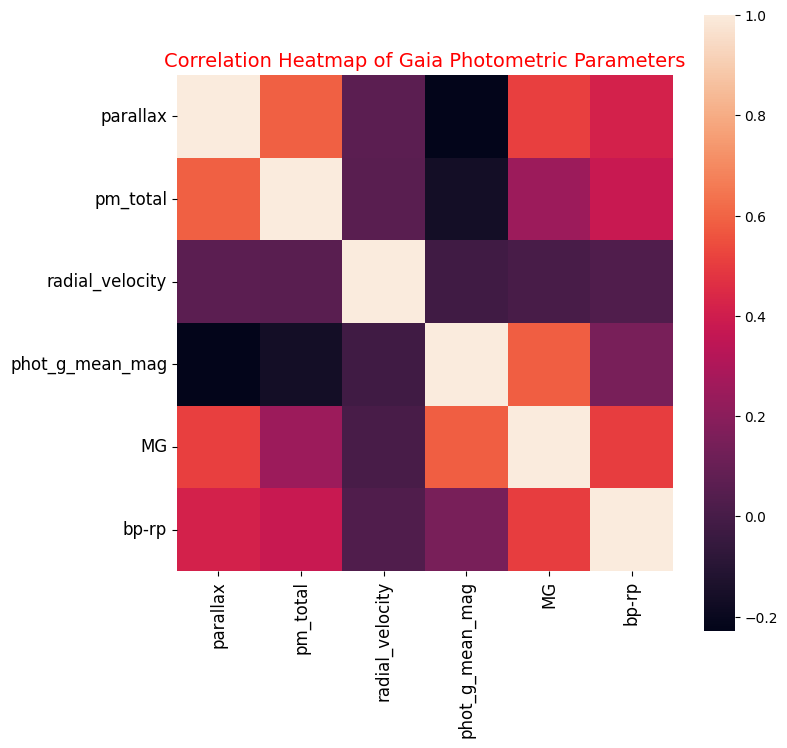

In [11]:
# columns for correlation analysis
correlation_columns = ['parallax','pm_total', 'radial_velocity','phot_g_mean_mag','MG', 'bp-rp']

# correlation map
corr = good_fit[correlation_columns].corr()

f, ax = plt.subplots(figsize=(8, 8))

ax = sns.heatmap(data=corr, square=True, ax=ax)
plt.title('Correlation Heatmap of Gaia Photometric Parameters',size=14, color="red")
ax.set_xticklabels(ax.xaxis.get_ticklabels(), fontsize=12, rotation=90)
ax.set_yticklabels(ax.yaxis.get_ticklabels(), fontsize=12, rotation=0)
plt.show()

#**5. Standardization**

###By looking at parallax, proper motion and radial velocity columns, we see a range a of number thus they need to be standardized to be usefull in ML.

In [12]:
standar = ['radial_velocity', 'parallax', 'pm_total', 'pmra', 'pmdec']

# drop missing values
scaled = good_fit.dropna(subset=standar).copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(scaled[standar])

# create new columns
scaled[['radial_velocity_scaled', 'parallax_scaled', 'pm_total_scaled', 'pmra_scaled', 'pmdec_scaled']] = scaled_data

# display the scaled data
scaled[['radial_velocity','radial_velocity_scaled', 'parallax','parallax_scaled','pm_total','pm_total_scaled']].head()

,radial_velocity,radial_velocity_scaled,parallax,parallax_scaled,pm_total,pm_total_scaled
48,5.786279,-0.122189,7.171825,1.812085,27.389872,0.618782
50,38.840103,0.797969,1.986501,-0.000574,3.947472,-0.456148
78,39.107105,0.805401,22.726467,7.249596,114.137892,4.596532
125,6.947568,-0.089861,1.604699,-0.134042,10.246514,-0.167311
132,10.378639,0.005654,1.333813,-0.228737,8.192129,-0.261513


#**6. Parallax before seperating the cluster members from background stars**

Peak parallax is approximately: 21.43 mas


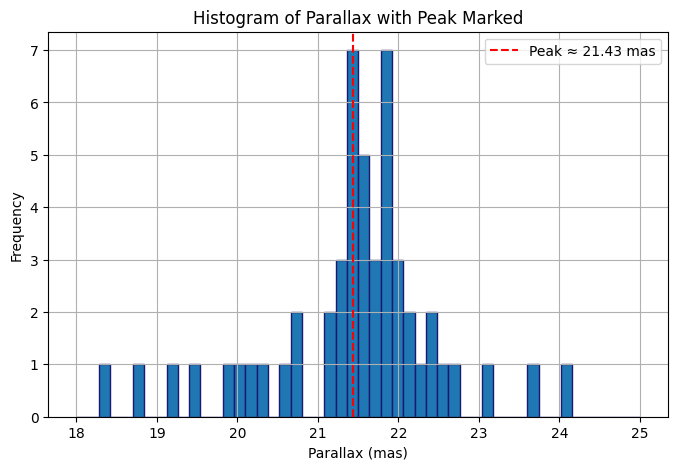

In [13]:
#find the peak of the parallax and compare it to the true value of parallax from literature review
counts, bin_edges = np.histogram(good_fit['parallax'], bins=50, range=(18, 25))

# bin with the highest count (citation:https://stackoverflow.com/questions/60060017/how-do-i-find-the-bin-with-the-highest-count-using-np-hist2d)
max_index = np.argmax(counts)
peak_bin_start = bin_edges[max_index]
peak_bin_end = bin_edges[max_index + 1]

# peak parallax as center of the bin
peak_parallax = (peak_bin_start + peak_bin_end) / 2

print(f"Peak parallax is approximately: {peak_parallax:.2f} mas")

# histogram with peak marked
plt.figure(figsize=(8, 5))
plt.hist(good_fit['parallax'], bins=50, range=(18, 25), edgecolor='midnightblue')
plt.axvline(peak_parallax, color='red', linestyle='--', label=f'Peak ≈ {peak_parallax:.2f} mas')
plt.xlabel('Parallax (mas)')
plt.ylabel('Frequency')
plt.title('Histogram of Parallax with Peak Marked')
plt.legend()
plt.grid(True)
plt.show()

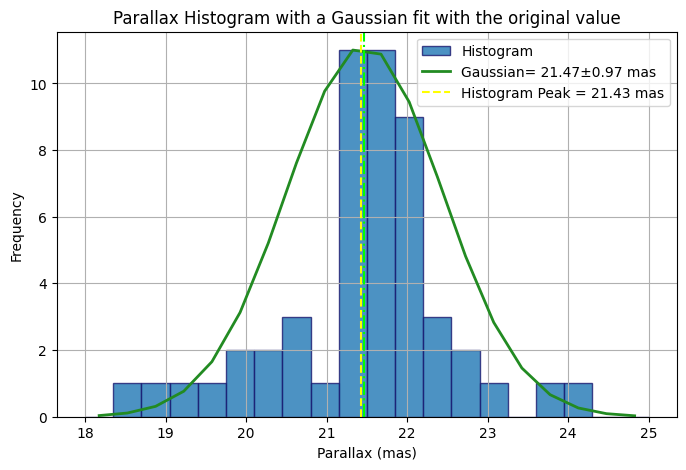

In [14]:
#Fit the real value of parallax as a Gaussian
counts, bin_edges = np.histogram(good_fit['parallax'], bins=20, range=(18, 25))
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# gaussian parameters (parallax values from literature review)
mean = 21.47
stddev = 0.97

# Gaussian
def gaussian(x, amp):
    return amp * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))

# fit Gaussian to the histogram (citation:https://stackoverflow.com/questions/11507028/fit-a-gaussian-function , https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html , https://stackoverflow.com/questions/77613077/fitting-a-gaussian-to-a-probability-distribution-to-find-the-standard-deviation)
initial_guess = [max(counts)]
params, _ = curve_fit(gaussian, bin_centers, counts, p0=initial_guess)
amp_fit= params

# scale the Gaussian to match histogram peak height
gaussian_vals = gaussian(bin_centers, *params)
scale_factor = max(counts) / max(gaussian_vals)
scaled_gaussian = gaussian_vals * scale_factor

plt.figure(figsize=(8, 5))
plt.hist(good_fit['parallax'], bins=20, range=(18, 25), edgecolor='midnightblue', alpha=0.8, label='Histogram')
plt.plot(bin_centers, scaled_gaussian, color='forestgreen', linewidth=2,label=f'Gaussian= {mean}±{stddev} mas')
plt.axvline(mean, color='lime', linestyle='-.' )
plt.axvline(peak_parallax, color='yellow', linestyle='--', label=f'Histogram Peak = {peak_parallax} mas')
plt.xlabel('Parallax (mas)')
plt.ylabel('Frequency')
plt.title('Parallax Histogram with a Gaussian fit with the original value')
plt.legend()
plt.grid(True)
plt.show()

###The parallax peak is 21.47. We can choose a range of 19.5 to 23 for the parallax

In [15]:
#filter parallax manually by the known value for comparison with K-mean results
parallax_filtered = good_fit[(good_fit['parallax']>=19.5) & (good_fit['parallax']<=23)]
print('Number of stars in the chosen range of parallax is:',len(parallax_filtered))

Number of stars in the chosen range of parallax is: 44


#**7. Proper motion before seperating the cluster members from background stars**

##The following plot uses the manually parallax filtered data and displays their proper motion behaviour in RA and DEC. The cluster is seperated with dashed lines.

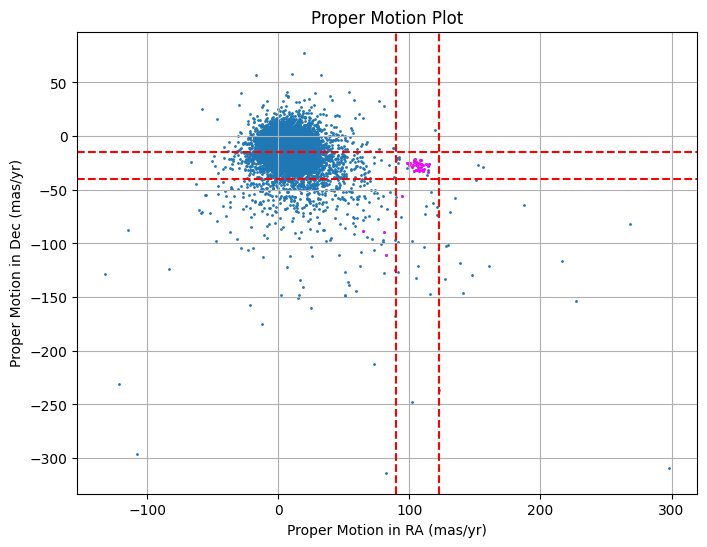

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(good_fit['pmra'], good_fit['pmdec'], s=1, alpha=1)
plt.scatter(parallax_filtered['pmra'], parallax_filtered['pmdec'], s=1, alpha=1, color="magenta")
plt.xlabel('Proper Motion in RA (mas/yr)')
plt.ylabel('Proper Motion in Dec (mas/yr)')
plt.axhline(y=-40, color='red', linestyle='--')
plt.axhline(y=-15, color='red', linestyle='--')
plt.axvline(x=90, color='red', linestyle='--')
plt.axvline(x=123, color='red', linestyle='--')
plt.title('Proper Motion Plot')
plt.grid(True)
plt.show()

## After filtering for parallax and proper motion manually using the real values from literature, we have a good visuall undrestanding from the position of the Hyades cluster.

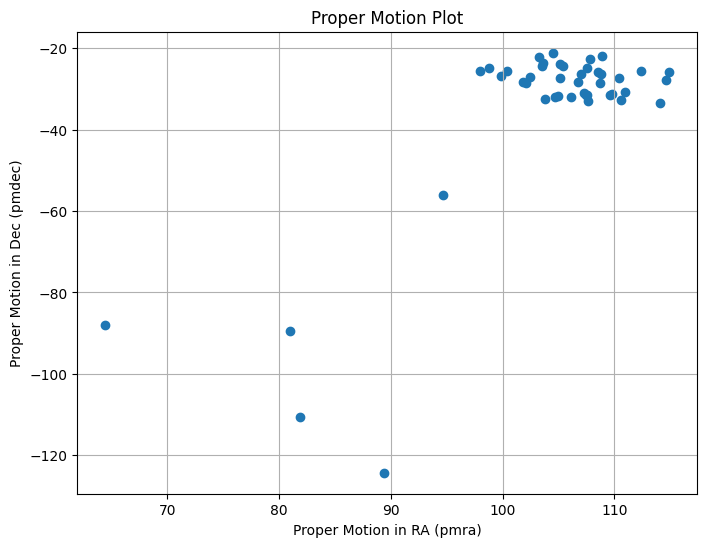

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(parallax_filtered['pmra'], parallax_filtered['pmdec'])
plt.xlabel('Proper Motion in RA (pmra)')
plt.ylabel('Proper Motion in Dec (pmdec)')
plt.title('Proper Motion Plot')
plt.grid(True)
plt.show()

#**8. K-mean Clustring**

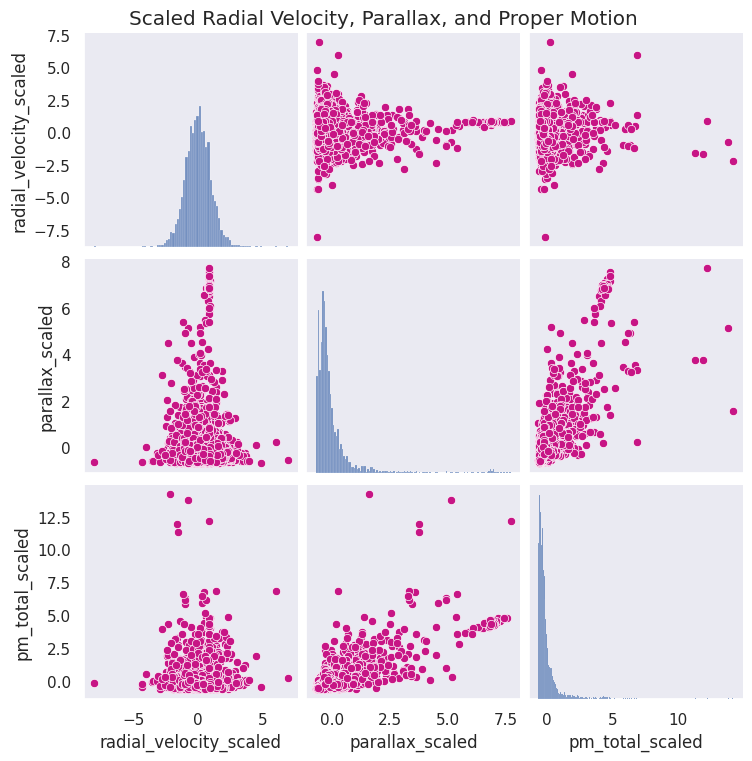

In [19]:
dfall = pd.DataFrame(scaled, columns=['radial_velocity_scaled', 'parallax_scaled', 'pm_total_scaled'])

sns.set(style="ticks", color_codes=True)
sns.set_style("dark")
sns.pairplot(dfall, plot_kws={'color': 'mediumvioletred'})
plt.suptitle("Scaled Radial Velocity, Parallax, and Proper Motion", y=1.01)
plt.show()

In [20]:
dfX = scaled[['radial_velocity_scaled', 'parallax_scaled', 'pm_total_scaled']]
model = KMeans(n_clusters=10, random_state=0)
scaled['kmeans_label'] = model.fit_predict(dfX)

predicted = model.labels_
centroids = model.cluster_centers_
dfX['predicted'] = predicted


dfX['pmra'] = scaled['pmra']
dfX['pmdec'] = scaled['pmdec']

dfX['ra']= scaled['ra']
dfX['dec']= scaled['dec']

dfX['radial_velocity']= scaled['radial_velocity']
dfX['parallax']= scaled['parallax']

dfX['phot_g_mean_mag']= scaled['phot_g_mean_mag']
dfX['phot_rp_mean_mag']= scaled['phot_rp_mean_mag']
dfX['phot_bp_mean_mag']= scaled['phot_bp_mean_mag']
dfX['bp-rp']= scaled['bp-rp']
dfX['MG']= scaled['MG']

<ipython-input-20-6da652614a34>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfX['predicted'] = predicted
<ipython-input-20-6da652614a34>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfX['pmra'] = scaled['pmra']
<ipython-input-20-6da652614a34>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.htm

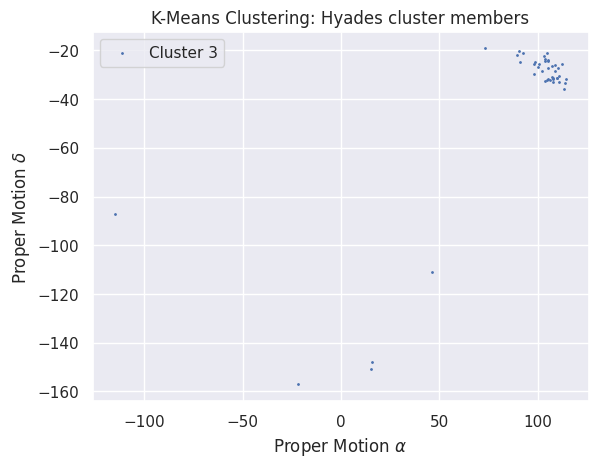

In [22]:
# #class_0 = scaled[scaled['kmeans_label'] == 0]
# plt.scatter(class_0['pmra'], class_0['pmdec'], s=1, alpha=1, label='Cluster 0')
# class_1 = scaled[scaled['kmeans_label'] == 1]
# #plt.scatter(class_1['pmra'], class_1['pmdec'], s=1, alpha=1, label='Cluster 1')
# class_2 = scaled[scaled['kmeans_label'] == 2]
# #plt.scatter(class_2['pmra'], class_2['pmdec'], s=1, alpha=1 , label='Cluster 2')
class_3 = scaled[scaled['kmeans_label'] == 3]
plt.scatter(class_3['pmra'], class_3['pmdec'], s=1, alpha=1 , label='Cluster 3')
# class_4 = scaled[scaled['kmeans_label'] == 4]
# #plt.scatter(class_4['pmra'], class_4['pmdec'], s=1, alpha=1 , label='Cluster 4')
# class_5 = scaled[scaled['kmeans_label'] == 5]
# #plt.scatter(class_5['pmra'], class_5['pmdec'], s=1, alpha=1 , label='Cluster 5')
# class_6 = scaled[scaled['kmeans_label'] == 6]
# #plt.scatter(class_6['pmra'], class_6['pmdec'], s=1, alpha=1 , label='Cluster 6')
# class_7 = scaled[scaled['kmeans_label'] == 7]
# #plt.scatter(class_7['pmra'], class_7['pmdec'], s=1, alpha=1 , label='Cluster 7')
# class_8 = scaled[scaled['kmeans_label'] == 8]
# #plt.scatter(class_8['pmra'], class_8['pmdec'], s=1, alpha=1 , label='Cluster 8')
# class_9 = scaled[scaled['kmeans_label'] == 9]
# #plt.scatter(class_9['pmra'], class_9['pmdec'], s=1, alpha=1 , label='Cluster 9')
plt.legend()
plt.title('K-Means Clustering: Hyades cluster members')
plt.xlabel(r'Proper Motion $\alpha$')
plt.ylabel(r'Proper Motion $\delta$')
plt.grid(True)
plt.show()

##By checking each class, it is seen that ***Cluster 3***  is the closest match to what we belive is the cluster.

In [22]:
cluster_members = scaled[scaled['kmeans_label'] == 3]

In [24]:
#cluster_members

## **Run K-mean on Parallax, Proper Motion and Radial velocity**

## a) Proper motion in space

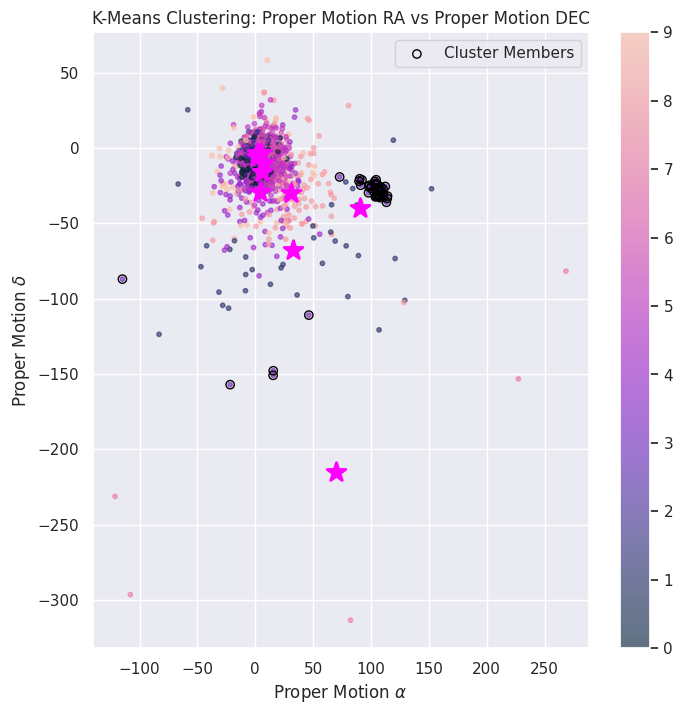

In [23]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(scaled['pmra'],scaled['pmdec'], c=scaled['kmeans_label'], cmap='cmr.bubblegum', alpha=0.6, s=10)

plt.scatter(cluster_members['pmra'], cluster_members['pmdec'], facecolors = 'none', edgecolors = 'black', label= 'Cluster Members')

#sorted samples based on K-mean centroids
for idx in np.arange(10):
    classified = scaled[scaled['kmeans_label'] == idx]
    x_cen = classified['pmra'].mean()
    y_cen = classified['pmdec'].mean()
    plt.scatter(x_cen, y_cen, marker='*', color='magenta', s=200, linewidths=2)

plt.title('K-Means Clustering: Proper Motion RA vs Proper Motion DEC')
plt.xlabel(r'Proper Motion $\alpha$')
plt.ylabel(r'Proper Motion $\delta$')
plt.grid(True)
plt.colorbar(scatter)
plt.legend()
plt.show()

## b) Proper Motion vs Parallax

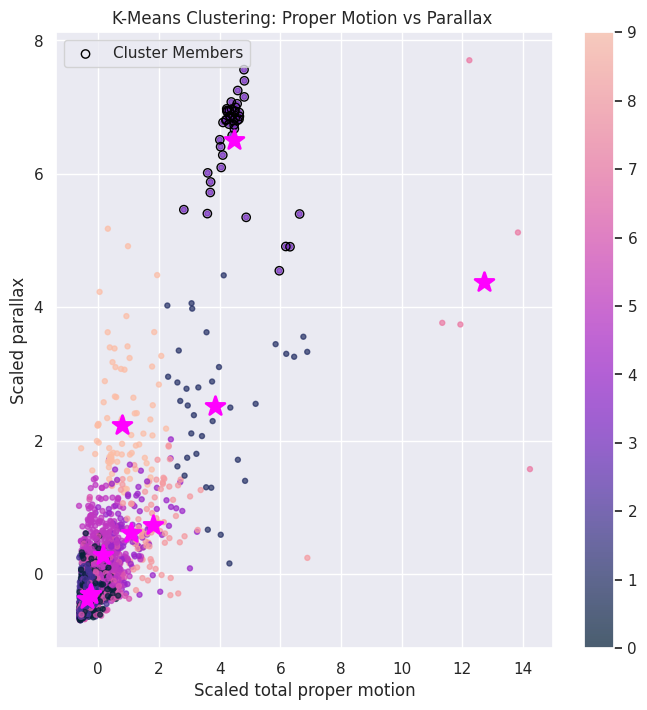

In [36]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(scaled['pm_total_scaled'], scaled['parallax_scaled'], c=scaled['kmeans_label'], cmap='cmr.bubblegum', alpha=0.7, s=13)

#Citation for "facecolors" and "edgecolors": https://stackoverflow.com/questions/4143502/how-to-do-a-scatter-plot-with-empty-circles-in-python
plt.scatter(cluster_members['pm_total_scaled'], cluster_members['parallax_scaled'], facecolors = 'none', edgecolors = 'black', label= 'Cluster Members')

for idx in np.arange(10):
    classified = scaled[scaled['kmeans_label'] == idx]
    x_cen = classified['pm_total_scaled'].mean()
    y_cen = classified['parallax_scaled'].mean()
    plt.scatter(x_cen, y_cen, marker='*', color='magenta', s=200, linewidths=2)

plt.title('K-Means Clustering: Proper Motion vs Parallax ')
plt.xlabel('Scaled total proper motion')
plt.ylabel('Scaled parallax')
plt.legend()
plt.grid(True)
plt.colorbar(scatter)
plt.show()

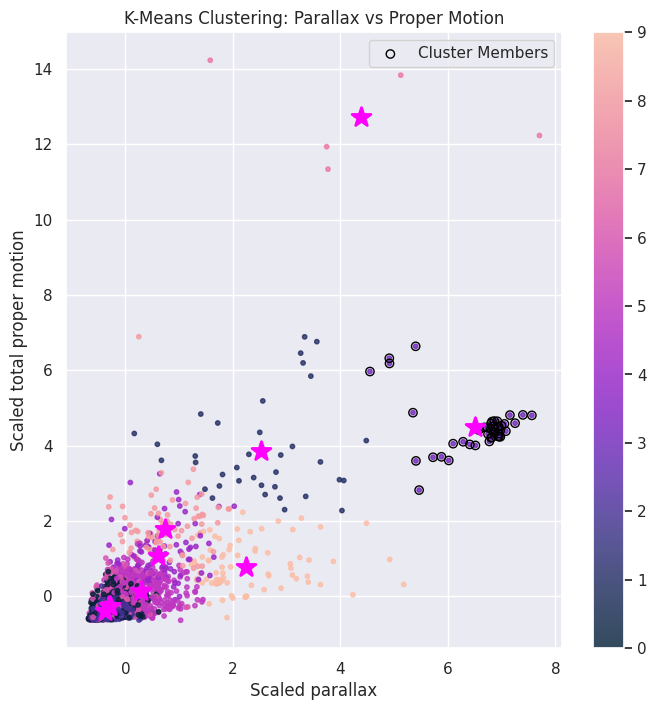

In [103]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(scaled['parallax_scaled'], scaled['pm_total_scaled'], c=scaled['kmeans_label'], cmap='cmr.bubblegum', alpha=0.8, s=10)

plt.scatter(cluster_members['parallax_scaled'], cluster_members['pm_total_scaled'], facecolors = 'none', edgecolors = 'black', label= 'Cluster Members')

for idx in np.arange(10):
    classified = scaled[scaled['kmeans_label'] == idx]
    x_cen = classified['parallax_scaled'].mean()
    y_cen = classified['pm_total_scaled'].mean()
    plt.scatter(x_cen, y_cen, marker='*', color='magenta', s=200, linewidths=2)

plt.title('K-Means Clustering: Parallax vs Proper Motion')
plt.xlabel('Scaled parallax')
plt.ylabel('Scaled total proper motion')
plt.grid(True)
plt.colorbar(scatter)
plt.legend()
plt.show()

## c) Proper Motion vs Radial Velocity

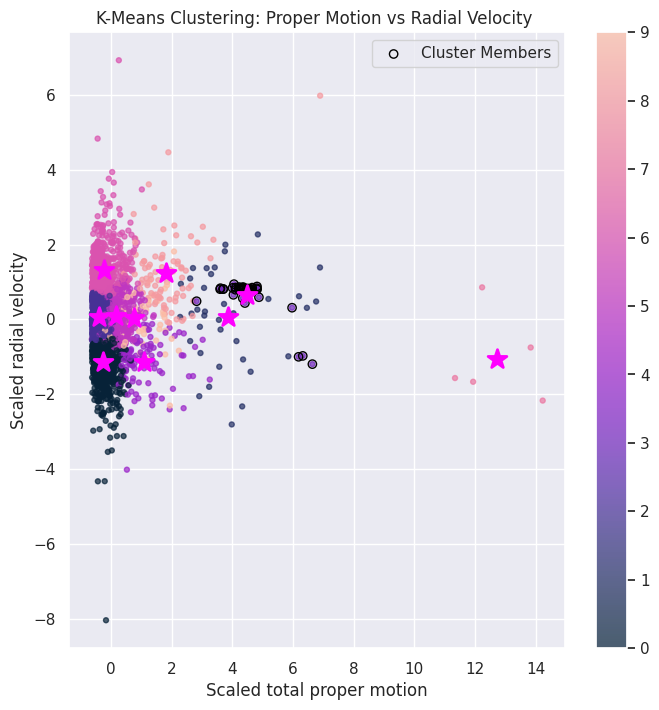

In [99]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(scaled['pm_total_scaled'], scaled['radial_velocity_scaled'], c=scaled['kmeans_label'], cmap='cmr.bubblegum', alpha=0.7, s=13)

plt.scatter(cluster_members['pm_total_scaled'], cluster_members['radial_velocity_scaled'], facecolors = 'none', edgecolors = 'black', label= 'Cluster Members')

for idx in np.arange(10):
    classified = scaled[scaled['kmeans_label'] == idx]
    x_cen = classified['pm_total_scaled'].mean()
    y_cen = classified['radial_velocity_scaled'].mean()
    plt.scatter(x_cen, y_cen, marker='*', color='magenta', s=200, linewidths=2)

plt.title('K-Means Clustering: Proper Motion vs Radial Velocity ')
plt.xlabel('Scaled total proper motion')
plt.ylabel('Scaled radial velocity')
plt.grid(True)
plt.colorbar(scatter)
plt.legend()
plt.show()

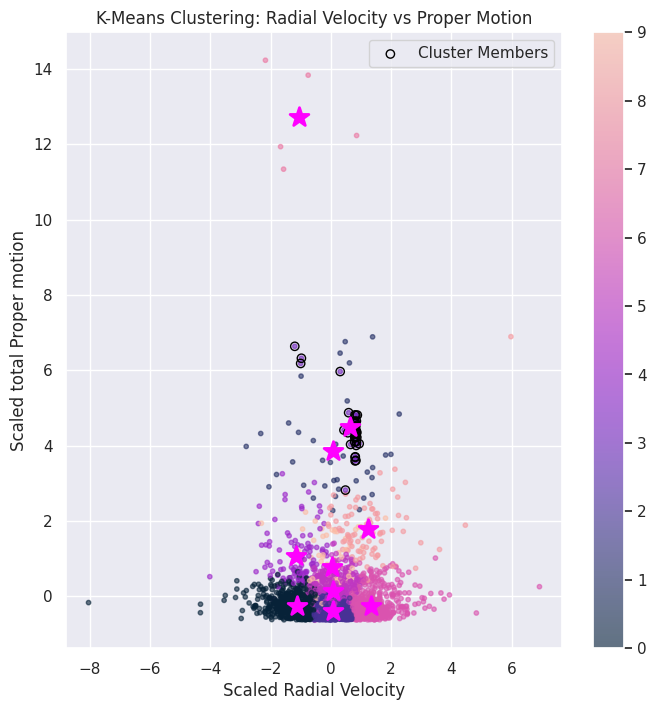

In [102]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(scaled['radial_velocity_scaled'],scaled['pm_total_scaled'], c=scaled['kmeans_label'], cmap='cmr.bubblegum', alpha=0.6, s=10)

plt.scatter(cluster_members['radial_velocity_scaled'], cluster_members['pm_total_scaled'], facecolors = 'none', edgecolors = 'black', label= 'Cluster Members')

for idx in np.arange(10):
    classified = scaled[scaled['kmeans_label'] == idx]
    x_cen = classified['radial_velocity_scaled'].mean()
    y_cen = classified['pm_total_scaled'].mean()
    plt.scatter(x_cen, y_cen, marker='*', color='magenta', s=200, linewidths=2)


plt.title('K-Means Clustering: Radial Velocity vs Proper Motion')
plt.xlabel('Scaled Radial Velocity')
plt.ylabel('Scaled total Proper motion')
plt.grid(True)
plt.colorbar(scatter)
plt.legend()
plt.show()

## d) Radial Velocity vs Parallax

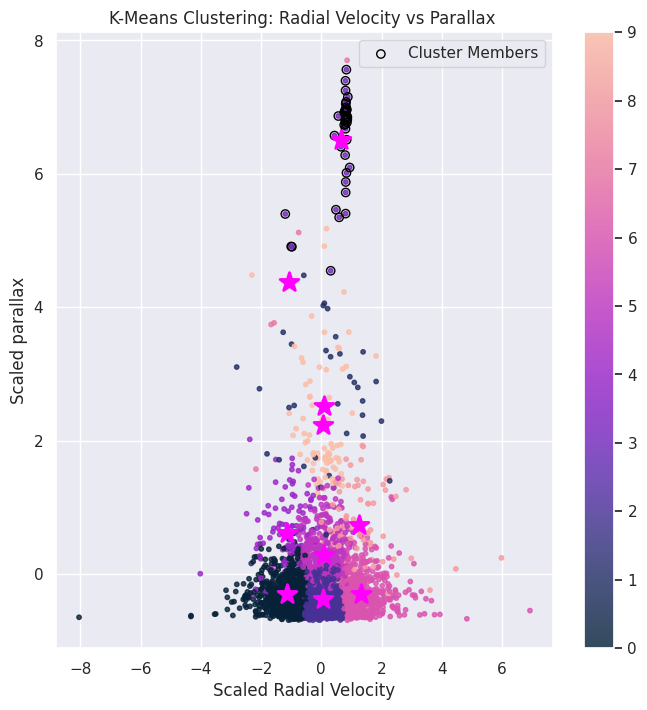

In [100]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(scaled['radial_velocity_scaled'], scaled['parallax_scaled'], c=scaled['kmeans_label'], cmap='cmr.bubblegum', alpha=0.8, s=10)

plt.scatter(cluster_members['radial_velocity_scaled'], cluster_members['parallax_scaled'], facecolors = 'none', edgecolors = 'black', label= 'Cluster Members')

for idx in np.arange(10):
    classified = scaled[scaled['kmeans_label'] == idx]
    x_cen = classified['radial_velocity_scaled'].mean()
    y_cen = classified['parallax_scaled'].mean()
    plt.scatter(x_cen, y_cen, marker='*', color='magenta', s=200, linewidths=2)

plt.title('K-Means Clustering: Radial Velocity vs Parallax ')
plt.xlabel('Scaled Radial Velocity')
plt.ylabel('Scaled parallax')
plt.grid(True)
plt.colorbar(scatter)
plt.legend()
plt.show()

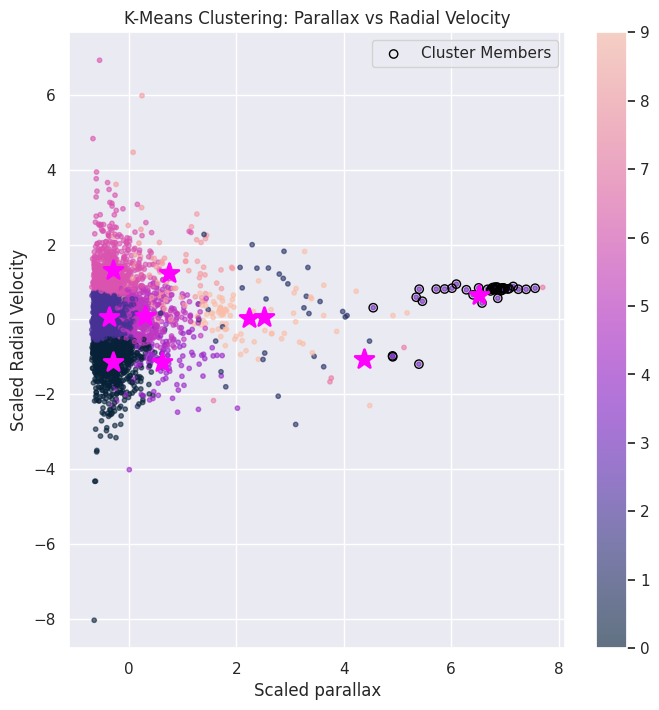

In [104]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(scaled['parallax_scaled'], scaled['radial_velocity_scaled'], c=scaled['kmeans_label'], cmap='cmr.bubblegum', alpha=0.6, s=10)

plt.scatter(cluster_members['parallax_scaled'], cluster_members['radial_velocity_scaled'], facecolors = 'none', edgecolors = 'black', label= 'Cluster Members')


for idx in np.arange(10):
    classified = scaled[scaled['kmeans_label'] == idx]
    x_cen = classified['parallax_scaled'].mean()
    y_cen = classified['radial_velocity_scaled'].mean()
    plt.scatter(x_cen, y_cen, marker='*', color='magenta', s=200, linewidths=2)

plt.title('K-Means Clustering: Parallax vs Radial Velocity')
plt.xlabel('Scaled parallax')
plt.ylabel('Scaled Radial Velocity')
plt.grid(True)
plt.colorbar(scatter)
plt.legend()
plt.show()

## e) Radial Velocity in space

## Cluster members are shown with yellow circles

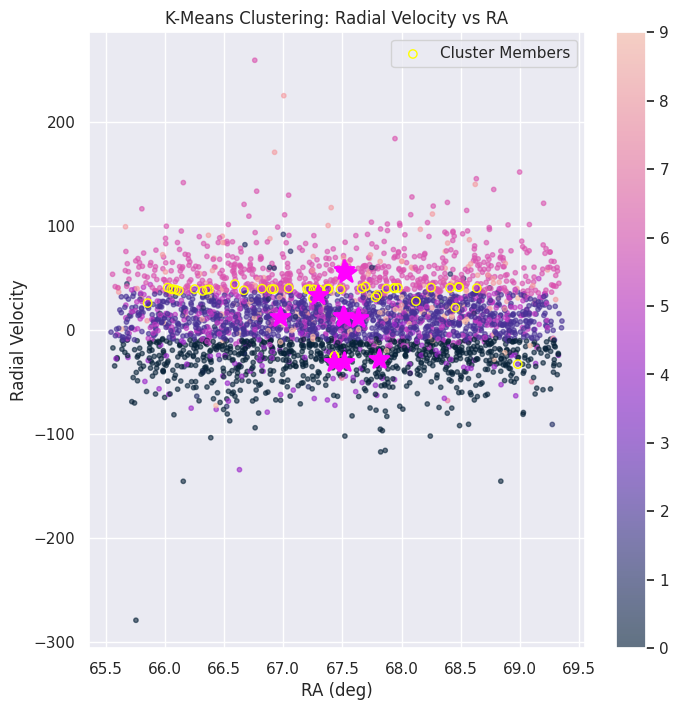

In [207]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(scaled['ra'], scaled['radial_velocity'], c=scaled['kmeans_label'], cmap='cmr.bubblegum', alpha=0.6, s=10)

plt.scatter(cluster_members['ra'], cluster_members['radial_velocity'], facecolors = 'none', edgecolors = 'yellow', label= 'Cluster Members')


for idx in np.arange(10):
    classified = scaled[scaled['kmeans_label'] == idx]
    x_cen = classified['ra'].mean()
    y_cen = classified['radial_velocity'].mean()
    plt.scatter(x_cen, y_cen, marker='*', color='magenta', s=200, linewidths=2)

plt.title('K-Means Clustering: Radial Velocity vs RA')
plt.xlabel('RA (deg)')
plt.ylabel('Radial Velocity')
plt.grid(True)
plt.colorbar(scatter)
plt.legend()
plt.show()

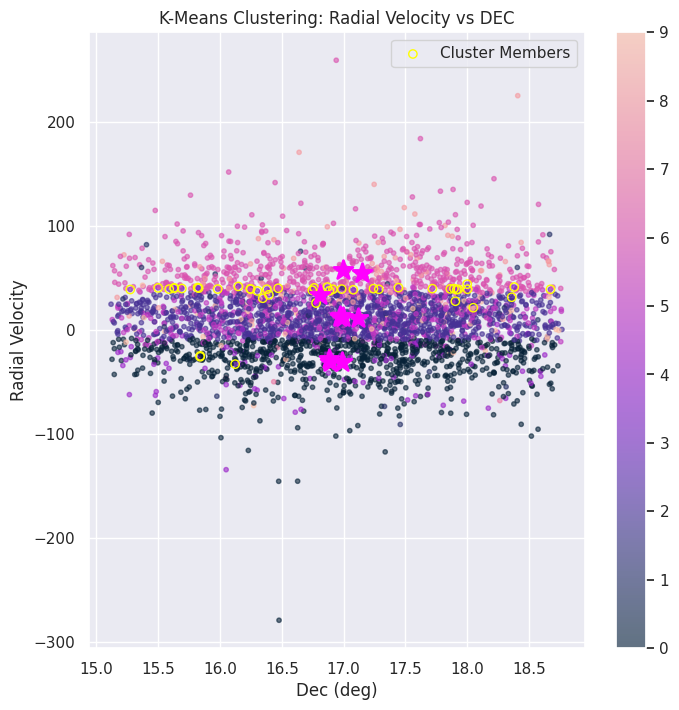

In [208]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(scaled['dec'], scaled['radial_velocity'], c=scaled['kmeans_label'], cmap='cmr.bubblegum', alpha=0.6, s=10)

plt.scatter(cluster_members['dec'], cluster_members['radial_velocity'], facecolors = 'none', edgecolors = 'yellow', label= 'Cluster Members')


for idx in np.arange(10):
    classified = scaled[scaled['kmeans_label'] == idx]
    x_cen = classified['dec'].mean()
    y_cen = classified['radial_velocity'].mean()
    plt.scatter(x_cen, y_cen, marker='*', color='magenta', s=200, linewidths=2)

plt.title('K-Means Clustering: Radial Velocity vs DEC')
plt.xlabel('Dec (deg)')
plt.ylabel('Radial Velocity')
plt.grid(True)
plt.colorbar(scatter)
plt.legend()
plt.show()

## Mean and standard deviation of radial velocity for cluster members

In [215]:
rv = cluster_members['radial_velocity'].mean()
print(f'Mean of Radial velocity mean for cluster members: {rv :.2f}')

st = cluster_members['radial_velocity'].std()
print(f'Standard deviation of Radial velocity for cluster members: {st :.2f}')

Mean of Radial velocity mean for cluster members: 33.42
Standard deviation of Radial velocity mean for cluster members: 17.55


## f) Parallax in space

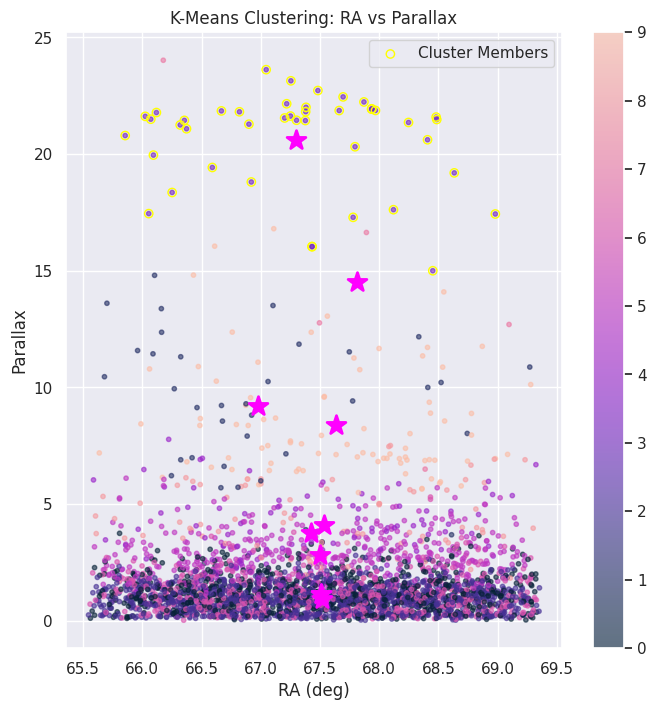

In [114]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(scaled['ra'], scaled['parallax'], c=scaled['kmeans_label'], cmap='cmr.bubblegum', alpha=0.6, s=10)

plt.scatter(cluster_members['ra'], cluster_members['parallax'], facecolors = 'none', edgecolors = 'yellow', label= 'Cluster Members')


for idx in np.arange(10):
    classified = scaled[scaled['kmeans_label'] == idx]
    x_cen = classified['ra'].mean()
    y_cen = classified['parallax'].mean()
    plt.scatter(x_cen, y_cen, marker='*', color='magenta', s=200, linewidths=2)

plt.title('K-Means Clustering: RA vs Parallax')
plt.xlabel('RA (deg)')
plt.ylabel('Parallax')
plt.grid(True)
plt.colorbar(scatter)
plt.legend()
plt.show()

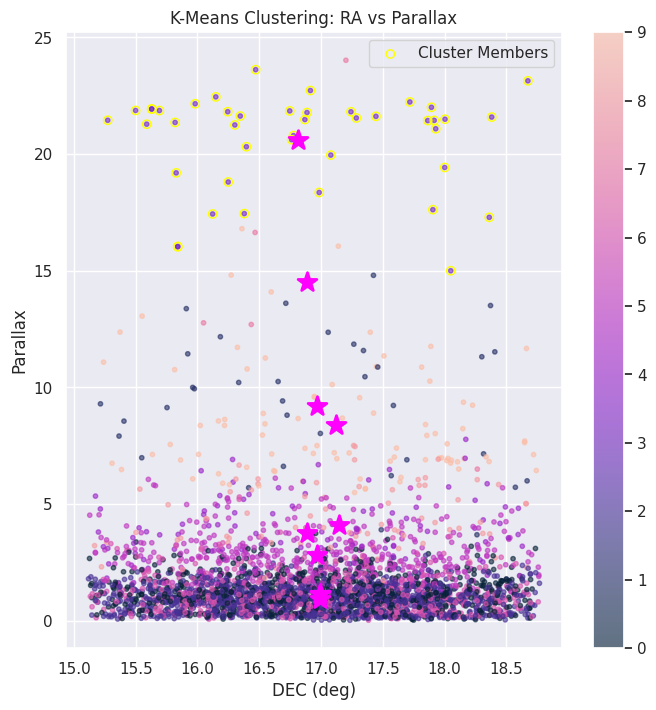

In [116]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(scaled['dec'], scaled['parallax'], c=scaled['kmeans_label'], cmap='cmr.bubblegum', alpha=0.6, s=10)

plt.scatter(cluster_members['dec'], cluster_members['parallax'], facecolors = 'none', edgecolors = 'yellow', label= 'Cluster Members')


for idx in np.arange(10):
    classified = scaled[scaled['kmeans_label'] == idx]
    x_cen = classified['dec'].mean()
    y_cen = classified['parallax'].mean()
    plt.scatter(x_cen, y_cen, marker='*', color='magenta', s=200, linewidths=2)

plt.title('K-Means Clustering: RA vs Parallax')
plt.xlabel('DEC (deg)')
plt.ylabel('Parallax')
plt.grid(True)
plt.colorbar(scatter)
plt.legend()
plt.show()

## Mean and standard deviation of parallax for cluster members

In [216]:
para= cluster_members['parallax'].mean()
print(f'Mean of Parallax for cluster members: {para :.2f}')

st = cluster_members['parallax'].std()
print(f'Standard deviation of Parallax for cluster members: {st :.2f}')


Mean of Parallax for cluster members: 20.61
Standard deviation of Parallax for cluster members: 2.06


# **9. Color Magnitude Diagrams**

## a) MG vs (BP - RP)

<ipython-input-217-62affe1f3c5d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_members['bp_rp'] = cluster_members['phot_bp_mean_mag'] - cluster_members['phot_rp_mean_mag']
<ipython-input-217-62affe1f3c5d>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_members['MG'] = cluster_members['phot_g_mean_mag'] + 5 * (np.log10(cluster_members['parallax'] / 1000) + 1)


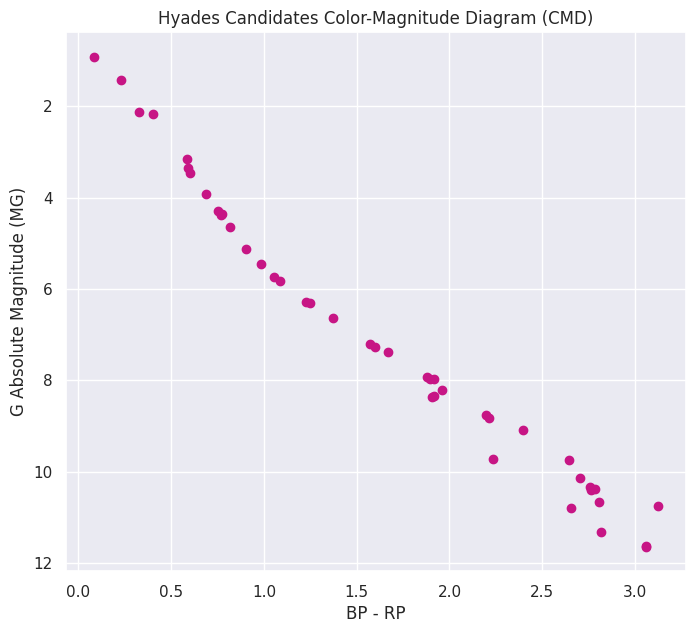

In [217]:
# color (BP - RP)
cluster_members['bp_rp'] = cluster_members['phot_bp_mean_mag'] - cluster_members['phot_rp_mean_mag']

# G absolute magnitude (MG)
cluster_members['MG'] = cluster_members['phot_g_mean_mag'] + 5 * (np.log10(cluster_members['parallax'] / 1000) + 1)

# CMD
plt.figure(figsize=(8, 7))
plt.scatter(cluster_members['bp_rp'], cluster_members['MG'], color="mediumvioletred")
plt.gca().invert_yaxis()  # Brighter stars on top
plt.xlabel('BP - RP')
plt.ylabel('G Absolute Magnitude (MG)')
plt.title('Hyades Candidates Color-Magnitude Diagram (CMD)')
plt.grid(True)
plt.show()

## b) MG vs (G - RP)

<ipython-input-218-bfd2e491be41>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_members['G-RP'] = cluster_members['phot_g_mean_mag'] - cluster_members['phot_rp_mean_mag']
<ipython-input-218-bfd2e491be41>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_members['MG'] = cluster_members['phot_g_mean_mag'] + 5 * (np.log10(cluster_members['parallax'] / 1000) + 1)


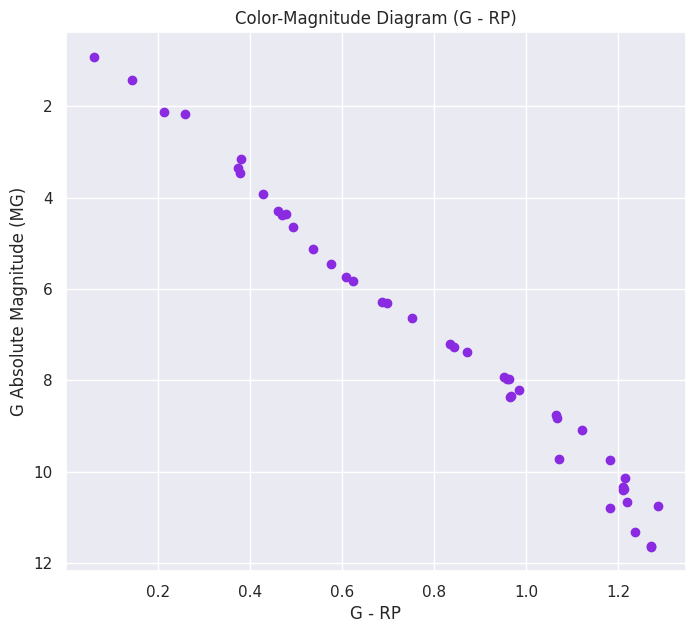

In [218]:
# G absolute magnitude
cluster_members['G-RP'] = cluster_members['phot_g_mean_mag'] - cluster_members['phot_rp_mean_mag']
cluster_members['MG'] = cluster_members['phot_g_mean_mag'] + 5 * (np.log10(cluster_members['parallax'] / 1000) + 1)

# CMD
plt.figure(figsize=(8, 7))
plt.scatter(cluster_members['G-RP'], cluster_members['MG'], color='blueviolet')
plt.gca().invert_yaxis()
plt.xlabel('G - RP')
plt.ylabel('G Absolute Magnitude (MG)')
plt.title('Color-Magnitude Diagram (G - RP)')
plt.grid(True)
plt.show()

# **10. Gaia Photometric conversion to Johnson-Cousins**

## MG vs (B-V) Color Magnitude Diagram

##This conversion has been problematic and full of errors, the final CMD does not agree with the previous ones which shows the code is not working properly.

In [179]:
cluster_members['V'] = cluster_members['phot_bp_mean_mag'] + 0.01760 + 0.006860*(cluster_members['bp_rp']) + (0.1732*(cluster_members['bp_rp'])**2)

cluster_members['R'] = cluster_members['phot_bp_mean_mag'] + 0.003226 - 0.3833*(cluster_members['bp_rp']) + (0.1345*(cluster_members['bp_rp'])**2)

m = []

#Citation on how to convert to Johnson-Cousins: https://gea.esac.esa.int/archive/documentation/GDR2/Data_processing/chap_cu5pho/sec_cu5pho_calibr/ssec_cu5pho_PhotTransf.html
#Citation for the following code: i searched google and Chatgpt on "How to solve a 3rd degree polynomial in python" with the Google colab AI because i got multiple errors in each step: https://en.moonbooks.org/Articles/How-to-solve-a-second-degree-equation-in-python-using-numpy-/ , https://stackoverflow.com/questions/15398427/solving-quadratic-equation
for source_id in cluster_members['source_id']:
    star = cluster_members[cluster_members['source_id'] == source_id]
    G_V = star['phot_g_mean_mag'].item() - star['V'].item()

    coefficients = [-0.001768, -0.2297, -0.02385, -0.02907-G_V]
    roots = np.roots(coefficients)
    real_roots = [root.real for root in roots if np.isclose(root.imag, 0, atol=1e-8)]

    # Filter the positive real roots
    positive_roots = real_roots[2]#real_roots[1]#[root for root in real_roots if root > 0]
    m.append(positive_roots)
    #print(G_V)
    #print(f"Source ID: {source_id}, Positive Roots: {positive_roots}")


cluster_members['B']= m + cluster_members['V']
cluster_members['B-V']= m

#cluster_members[['R','B','V']]



<ipython-input-179-de5eb2d5a190>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_members['V'] = cluster_members['phot_bp_mean_mag'] + 0.01760 + 0.006860*(cluster_members['bp_rp']) + (0.1732*(cluster_members['bp_rp'])**2)
<ipython-input-179-de5eb2d5a190>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_members['R'] = cluster_members['phot_bp_mean_mag'] + 0.003226 - 0.3833*(cluster_members['bp_rp']) + (0.1345*(cluster_members['bp_rp'])**2)
<ipython-input-179-de5eb2d5a190>:24: SettingWithCopyW

<ipython-input-219-2b8a3e5a87ca>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_members['MG'] = cluster_members['phot_g_mean_mag'] + 5 * (np.log10(cluster_members['parallax'] / 1000) + 1)


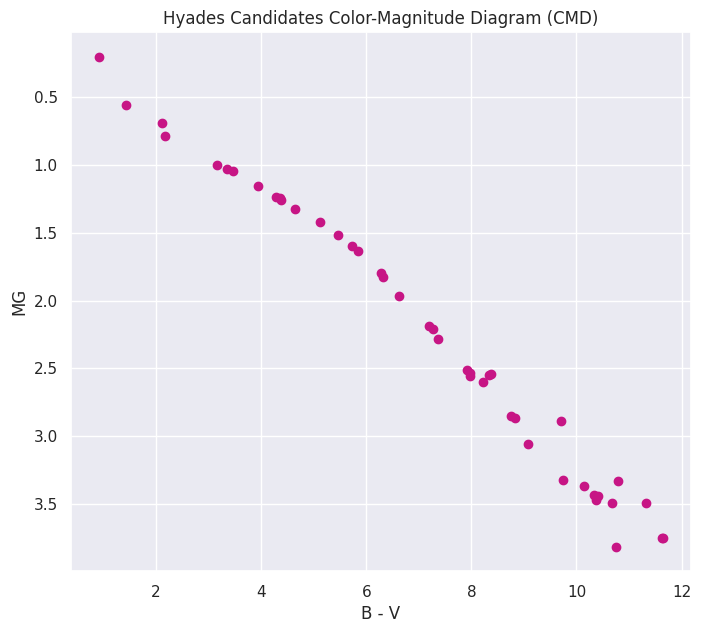

In [219]:
# G absolute magnitude (MG)
cluster_members['MG'] = cluster_members['phot_g_mean_mag'] + 5 * (np.log10(cluster_members['parallax'] / 1000) + 1)

# CMD (BP - RP vs MG)
plt.figure(figsize=(8, 7))
plt.scatter(cluster_members['MG'],cluster_members['B-V'], color="mediumvioletred")
plt.gca().invert_yaxis()  # Brighter stars on top
plt.xlabel('B - V')
plt.ylabel('MG')
plt.title('Hyades Candidates Color-Magnitude Diagram (CMD)')
plt.grid(True)
plt.show()